## Introduction
The analysis of Spotify songs, characterized by a rich set of features such as danceability, energy, and valence, holds significant importance in the realm of music research, entertainment, and data-driven decision-making. Understanding the musical attributes of songs through data analysis provides valuable insights into user preferences, genre trends, and the overall landscape of the music industry. This type of analysis contributes to personalized recommendations for users, enhancing their music discovery experience. Moreover, it aids music producers and artists in tailoring their creations to align with popular trends and audience preferences. Additionally, the exploration of Spotify song data has the potential to uncover patterns, correlations, and anomalies that can inform marketing strategies, playlist curation, and even influence the strategic planning of music events. Overall, the analysis of Spotify songs is instrumental in leveraging data to enhance user experiences, guide artistic endeavors, and inform strategic decisions within the dynamic and ever-evolving music industry.

## Requirements

In [7]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## **The Spotify Songs Dataset**

## Downloading the Spotify Songs Dataset

In [49]:
!gdown 1ayxWv-hlQdzGoHMnrtNWRae9YxlTFP-_

'gdown' is not recognized as an internal or external command,
operable program or batch file.


## Exploring the Spotify Songs Dataset
The dataset consists of information on more than 30,000 songs obtained from the Spotify API, with various musical features and genres. The features include danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, and genre. Each feature provides insights into different aspects of the songs, such as danceability, intensity, loudness, presence of spoken words, acoustic nature, instrumental content, live performance likelihood, musical positiveness, tempo, and genre. All these features except 'genre' serve as input variables for potential analysis and modeling. The 'genre' attribute serves as the target variable, representing the song genre to be predicted. The dataset offers a comprehensive collection of attributes, making it suitable for exploring and understanding the musical characteristics of a diverse range of songs.

**Loading the dataset into a `pandas` data frame.**

In [9]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [10]:
df=pd.read_csv('spotify-songs.csv')
df = df.copy(deep=True)
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,pop
1,0.726,NaN,-4.969,0.0373,0.0724,NaN,0.3570,0.693,99.972,pop
2,0.675,0.931,-3.432,0.0742,0.0794,NaN,0.1100,0.613,124.008,pop
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,NaN,pop
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,pop


In [86]:
print("Dataset shape:", df.shape)

Dataset shape: (32833, 10)


-Encoding the target variable using the `LabelEncoder` from the `scikit-learn` library.

In [11]:
le = LabelEncoder()
df['genre']= le.fit_transform(df['genre'])

## -Exploring the dataset using **Visualizations**.

In [50]:
ds = df['genre'].value_counts()
ds

genre
0    6043
4    5746
2    5507
3    5431
1    5155
5    4951
Name: count, dtype: int64

<Axes: xlabel='genre'>

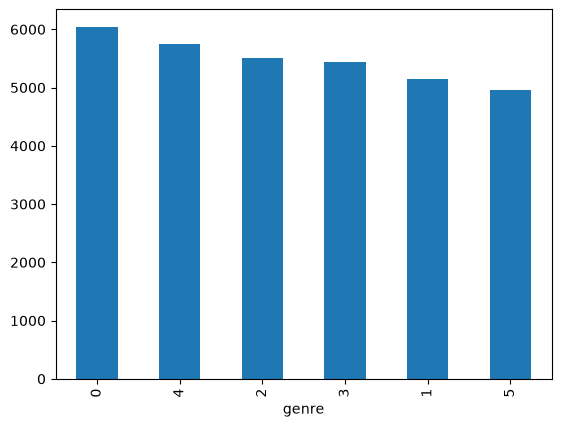

In [13]:
ds.plot.bar()

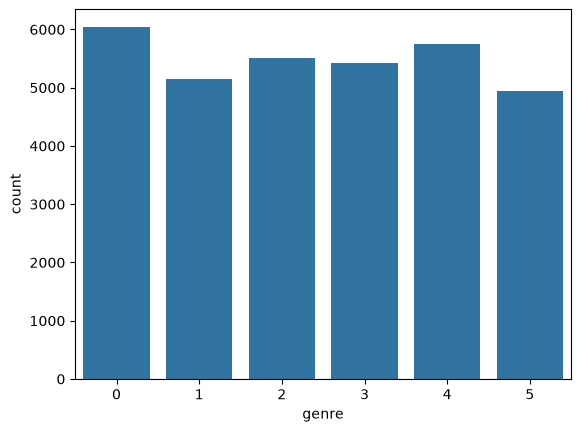

In [14]:
sns.countplot(x='genre', data=df)
plt.show()

-Checking if the dataset is balanced.

In [15]:
class_proportions = df['genre'].value_counts(normalize=True)
print(class_proportions)

genre
0    0.184053
4    0.175007
2    0.167728
3    0.165413
1    0.157007
5    0.150793
Name: proportion, dtype: float64


## Detecting Missing Values
-Calculating the percentage of missing values present in each column of the dataset.

In [51]:
missing_values_df = df.isnull().sum()
percentage_df = 100 * df.isnull().sum() / len(df)
missing_values_table_df = pd.concat([missing_values_df, percentage_df], axis=1)
missing_values_table_df.columns = ['Num. of missing values','% of missing values']
missing_values_table_df

,Num. of missing values,% of missing values
danceability,3662,11.153413
energy,11261,34.297810
loudness,7620,23.208357
speechiness,2361,7.190936
acousticness,894,2.722870
instrumentalness,6470,19.705784
liveness,2986,9.094509
valence,7489,22.809369
tempo,6557,19.970761
genre,0,0.000000


## Visualization
-With tools such as heatmaps, dendrograms, matrices and bar charts with the `missingno` library.

<Axes: >

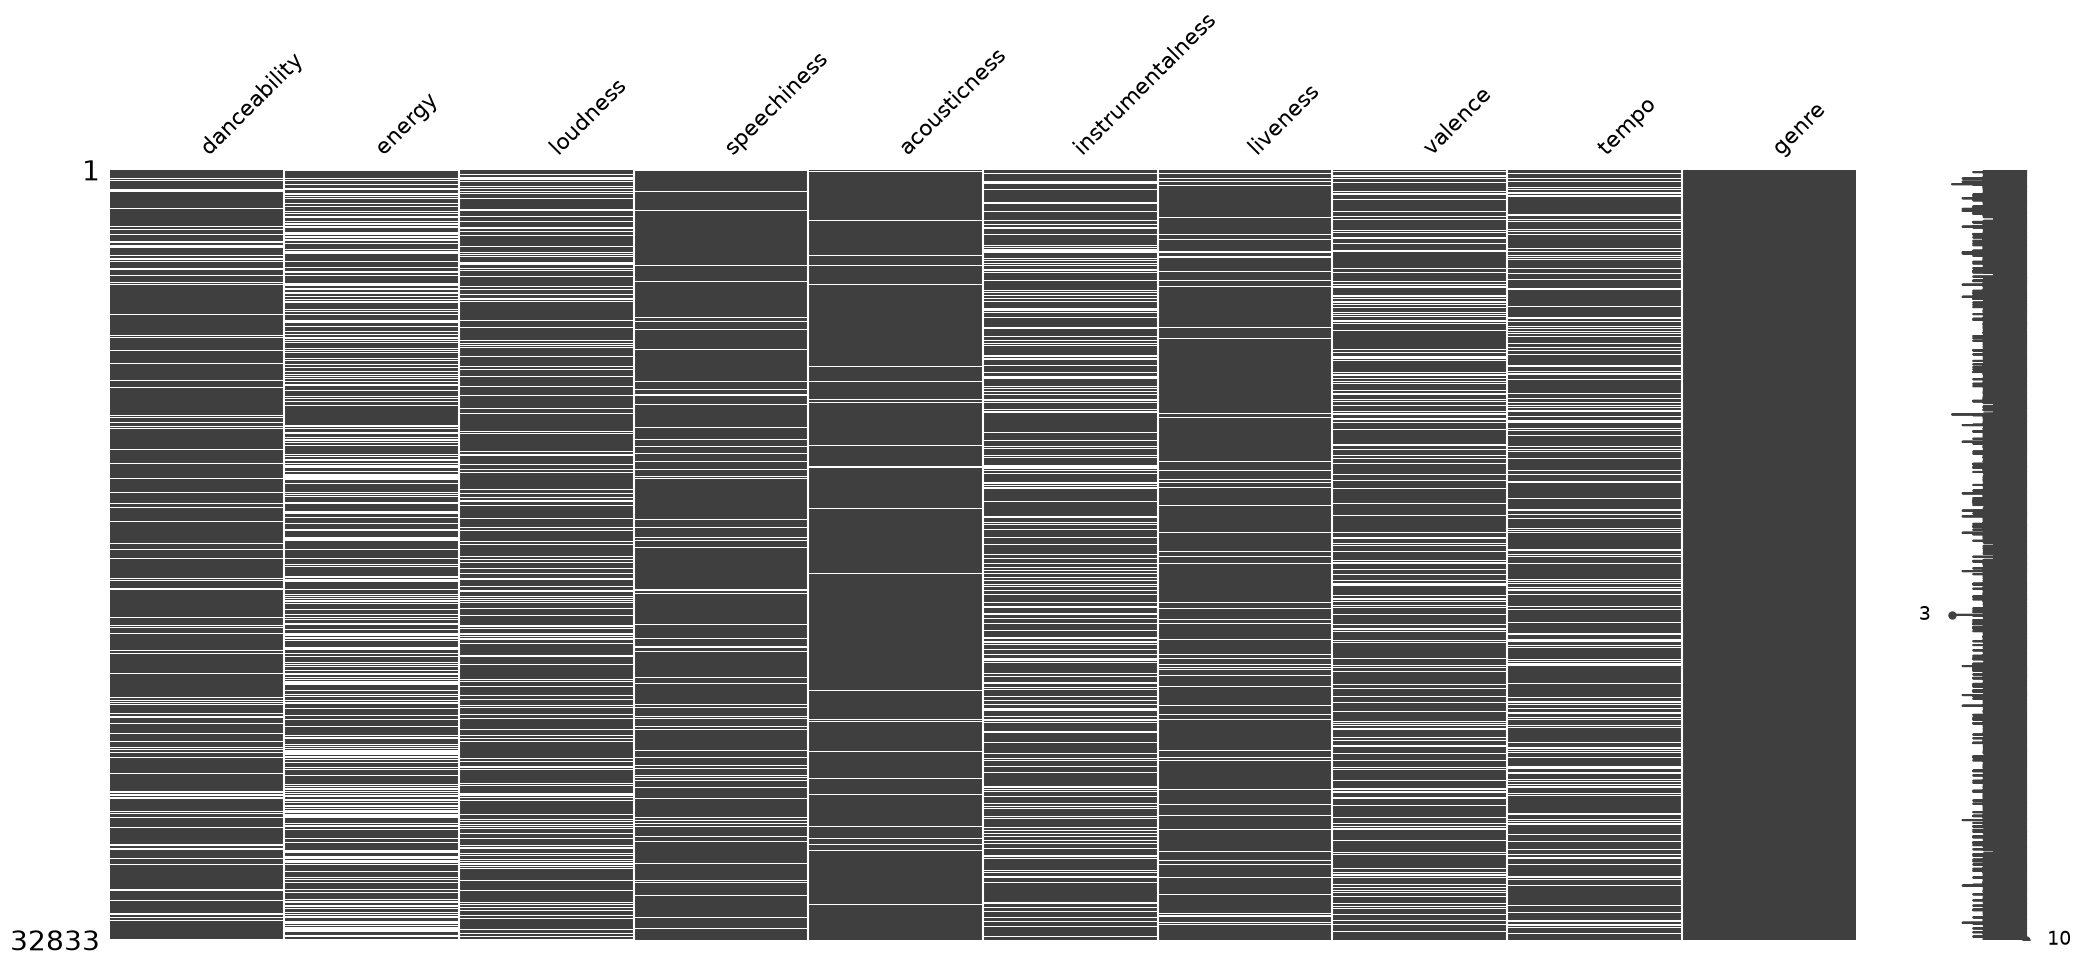

In [72]:
msno.matrix(df)

<Axes: >

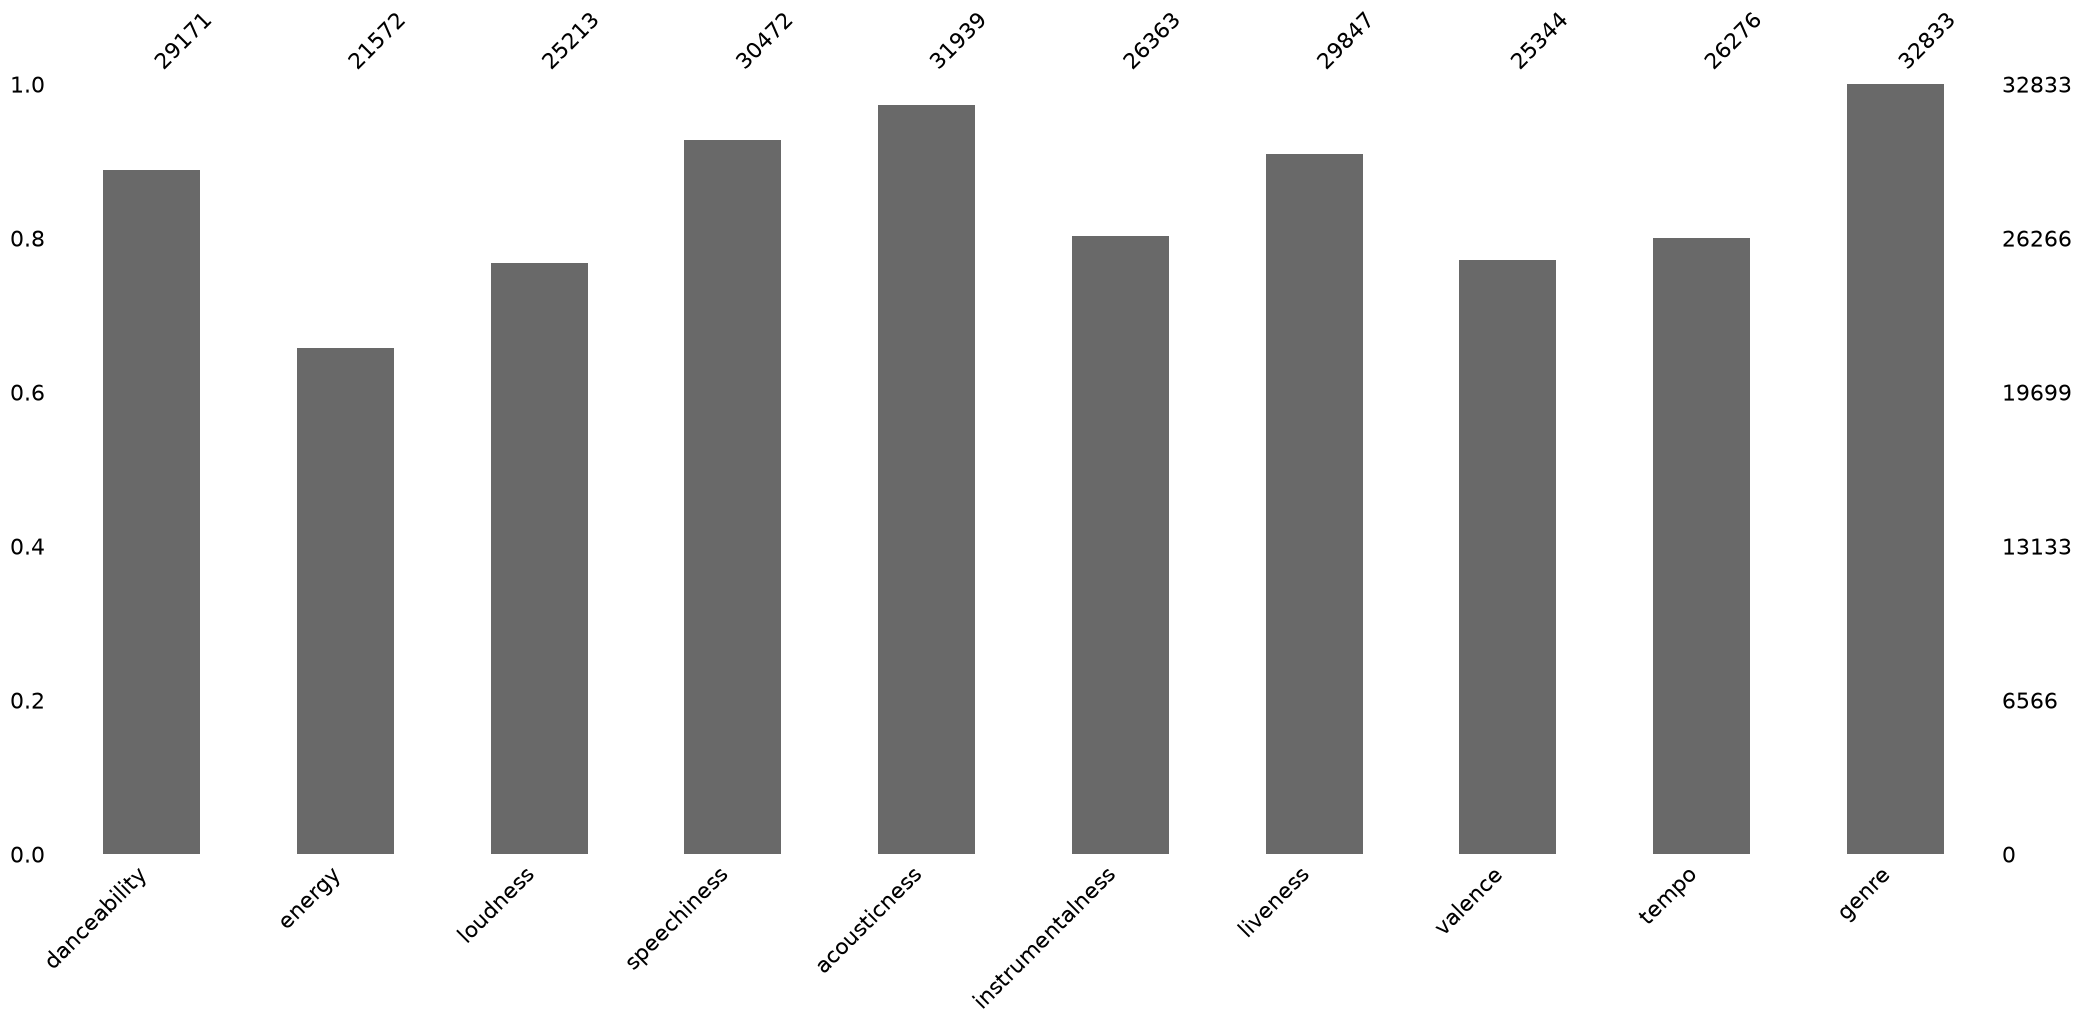

In [73]:
msno.bar(df)

<Axes: >

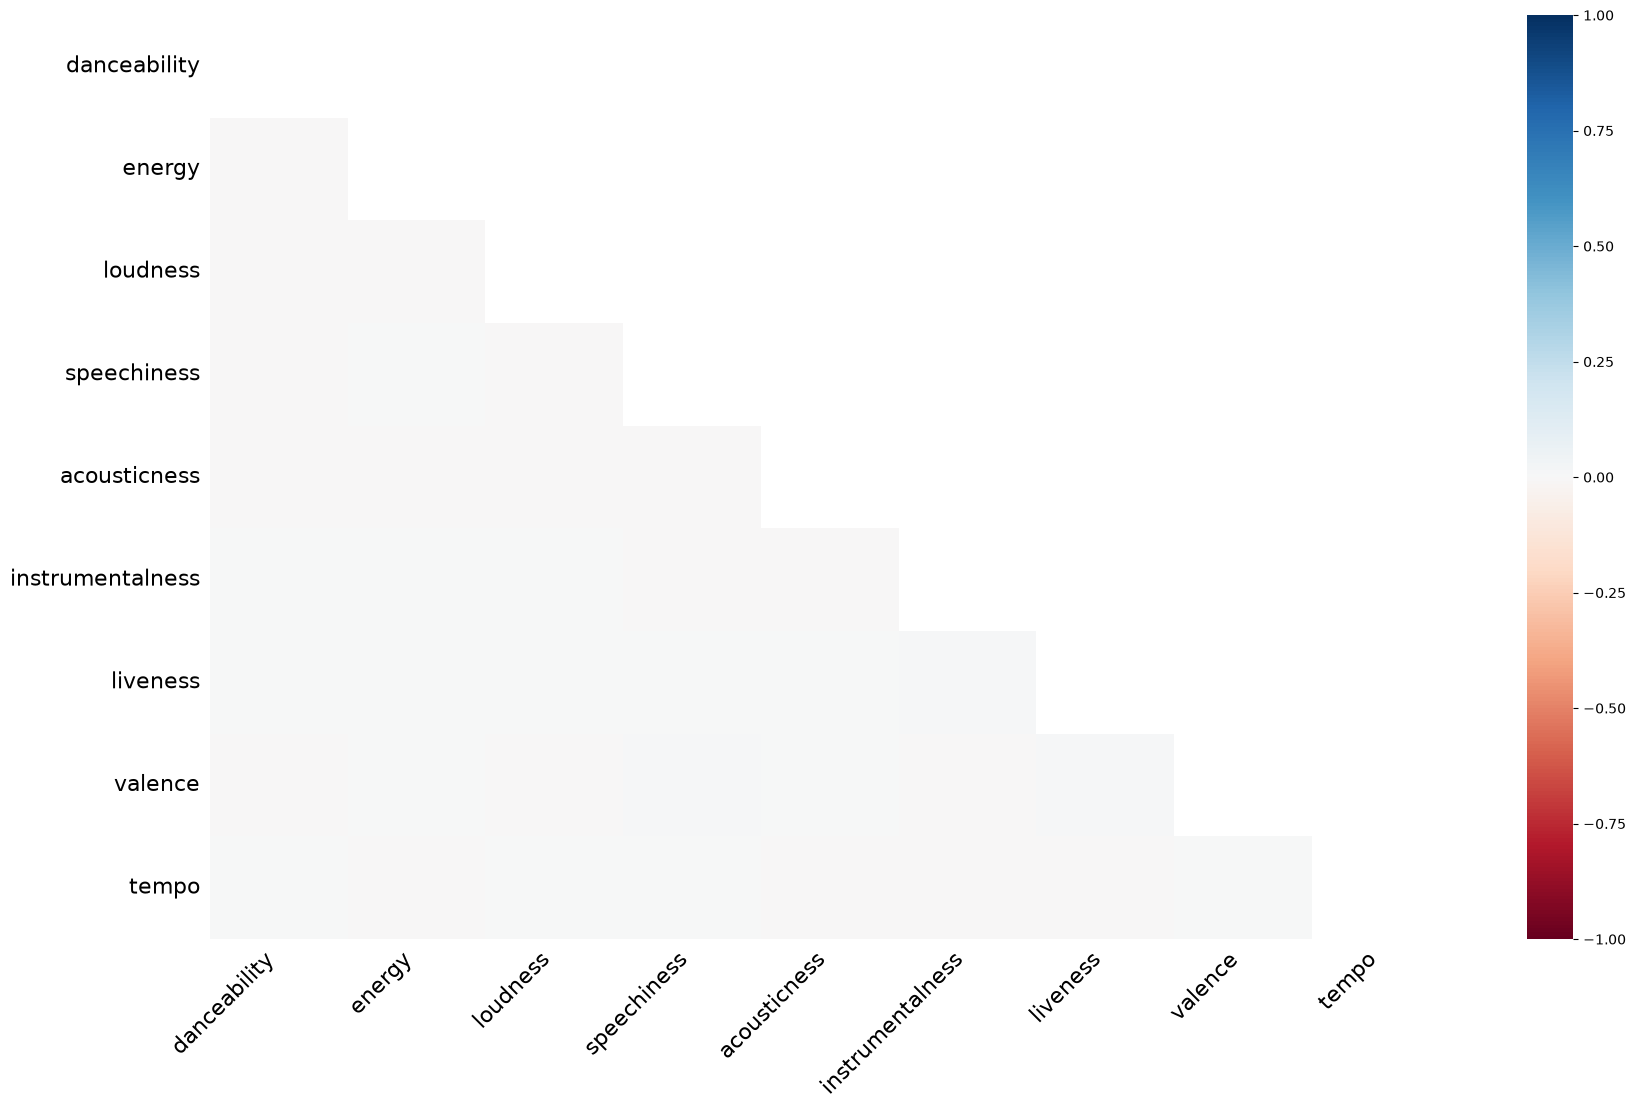

In [74]:
msno.heatmap(df)

<Axes: >

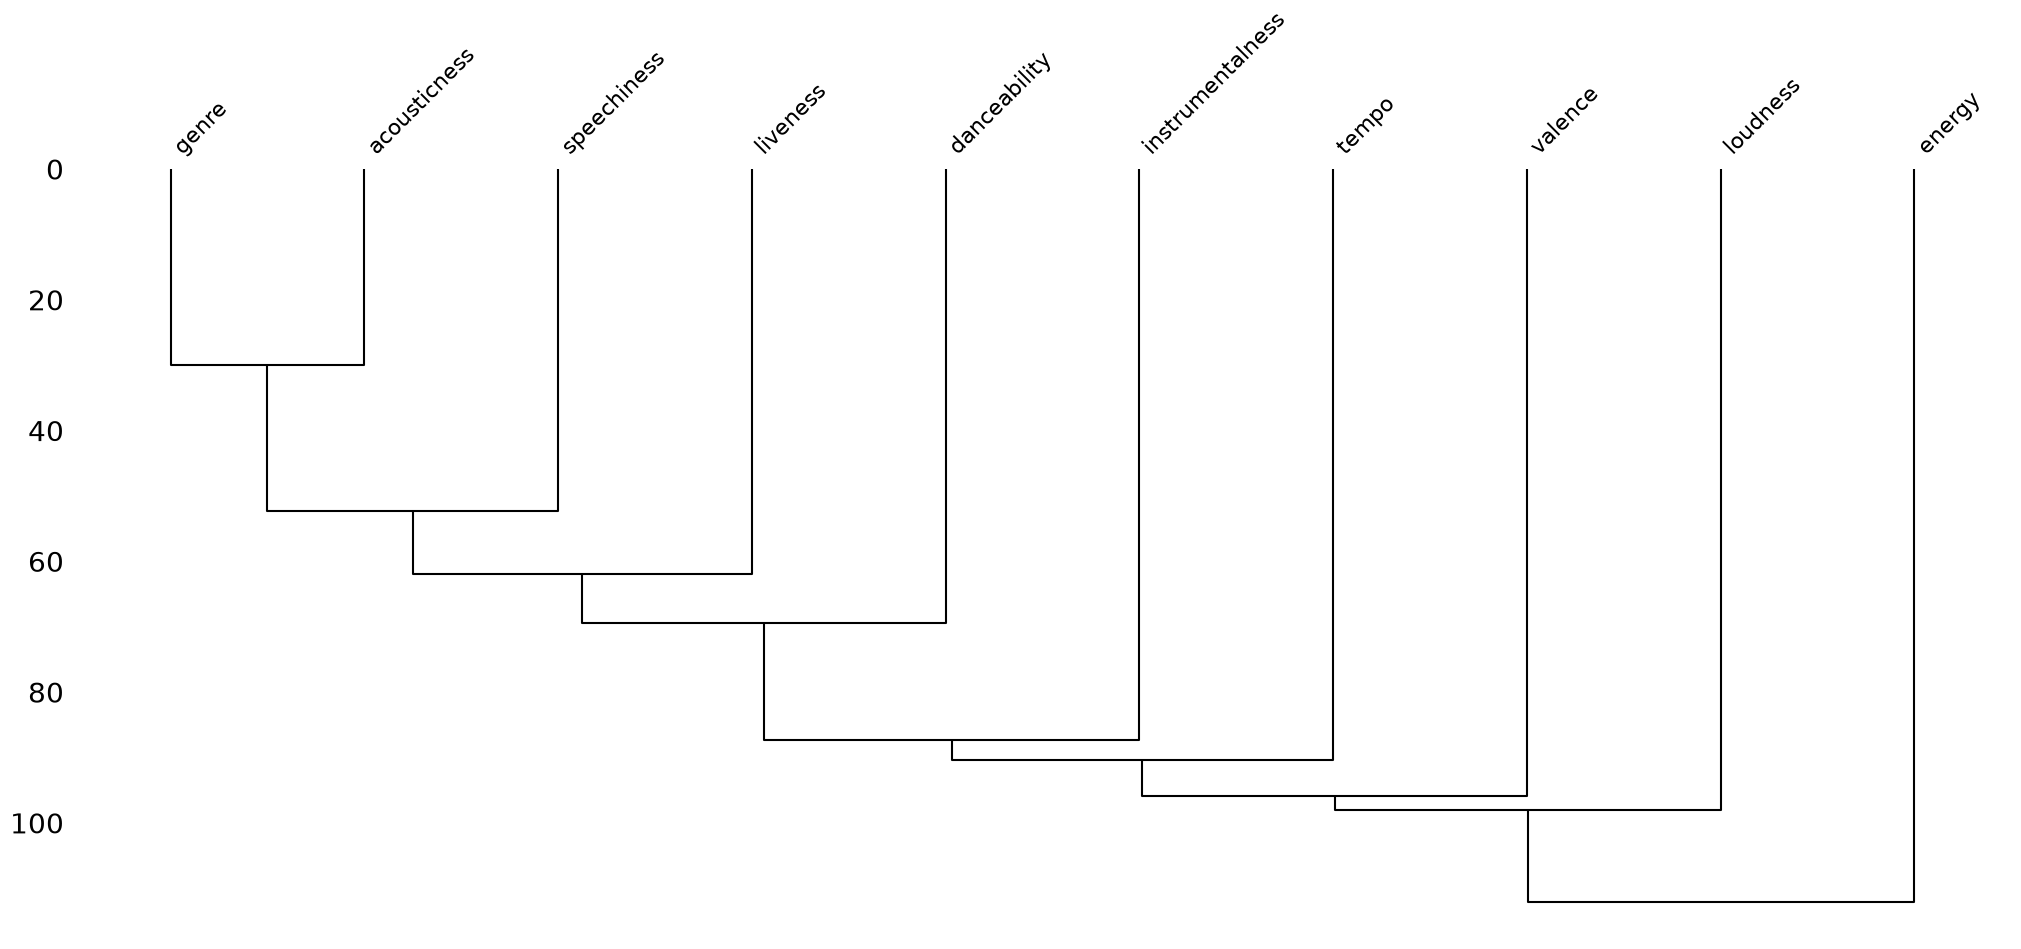

In [75]:
msno.dendrogram(df)

## Dataset Splitting
-Partition the dataset into training and testing sets with an 80:20 ratio.

In [77]:
#Split features
X = df.drop('genre', axis=1)
y = df['genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Handling the Missing Values

In [78]:
# Handling Missing Values
imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## Feature Scaling
-Standardizing the features using `MinMaxScaler`.

In [79]:
# Feature Scaling
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## K-Nearset Neighbors Classification

-Creating an instance of the KNN Classification model and training it using the `fit` function.

In [80]:
#Creating the model
knn = KNeighborsClassifier(n_neighbors=5)

#Training the model
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](6,)","[0,1,2,3,4,5]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


-Using the trained model to make predictions for the test set.

In [81]:
#Predictions
y_pred = knn.predict(X_test)

-Assessing the performance of the model by using different classification metrics provided by the `scikit-learn` library.

In [82]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.387


In [83]:
print(confusion_matrix(y_test, y_pred))

[[759 128 150  63  46  72]
 [193 360 167 139 114  60]
 [274 183 261 174  68 121]
 [140 198 155 296 161  81]
 [160 204 125 204 439  36]
 [178 105 193 106  27 427]]


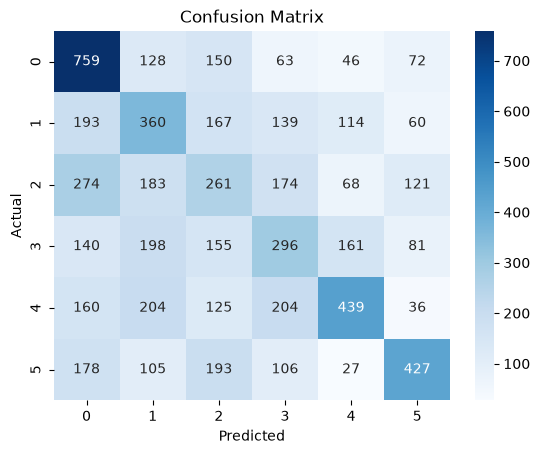

In [84]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.62      0.52      1218
           1       0.31      0.35      0.33      1033
           2       0.25      0.24      0.24      1081
           3       0.30      0.29      0.29      1031
           4       0.51      0.38      0.43      1168
           5       0.54      0.41      0.47      1036

    accuracy                           0.39      6567
   macro avg       0.39      0.38      0.38      6567
weighted avg       0.39      0.39      0.38      6567

